In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
internal_PC_dir = os.getcwd()
internal_MPC_dir = os.path.abspath(os.path.join(internal_PC_dir, '..'))
root_dir = os.path.abspath(os.path.join(internal_MPC_dir, '..'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
internal_1WSM_dir = os.path.abspath(os.path.join(internal_MPC_dir, '1_Without_System_model'))
internal_2WSM_dir = os.path.abspath(os.path.join(internal_MPC_dir, '2_With_System_model'))
sys.path.append(internal_CP_dir)
import Common_Params as CP

In [2]:
without_system_model_path = os.path.abspath(os.path.join(internal_1WSM_dir, 'store_results_data'))
with_system_model_path = os.path.abspath(os.path.join(internal_2WSM_dir, 'store_results_data'))

In [3]:
for i, file in enumerate(os.listdir(without_system_model_path)):
    if file == 'times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_times_without_system_model = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_seperations_without_system_model = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_velocities_without_system_model = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_accelerations_without_system_model = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_detected_times_without_system_model = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_start_reaction_times_without_sytem_model = pickle.load(f)
    else:
        print('ERROR')            

In [4]:
for i, file in enumerate(os.listdir(with_system_model_path)):
    if file == 'times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_times_with_system_model = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_seperations_with_system_model = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_velocities_with_system_model = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_accelerations_with_system_model = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_detected_times_with_system_model = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_start_reaction_times_with_sytem_model = pickle.load(f)
    else:
        print('ERROR')            

In [5]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp):
    fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness

    axes[0].plot(store_times[0], store_seperations[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[0].plot(store_times[1], store_seperations[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[0].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[0].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[0].plot(store_times[0], [CP.Dd + CP.Td * Vp for _ in range(len(store_seperations[0]))], label = f'Desired final seperation', color = 'green', linewidth = 6)
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Seperation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[1].plot(store_times[1], store_velocities[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[1].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[1].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[1].plot(store_times[0], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))], label = f'Desired final velocity', color = 'green', linewidth = 4)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    axes[2].plot(store_times[0], store_accelerations[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[2].plot(store_times[1], store_accelerations[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[2].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[2].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[2].grid(True, linewidth = 4.0)
    axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
    axes[2].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[2].legend(fontsize = font)

    plt.show()

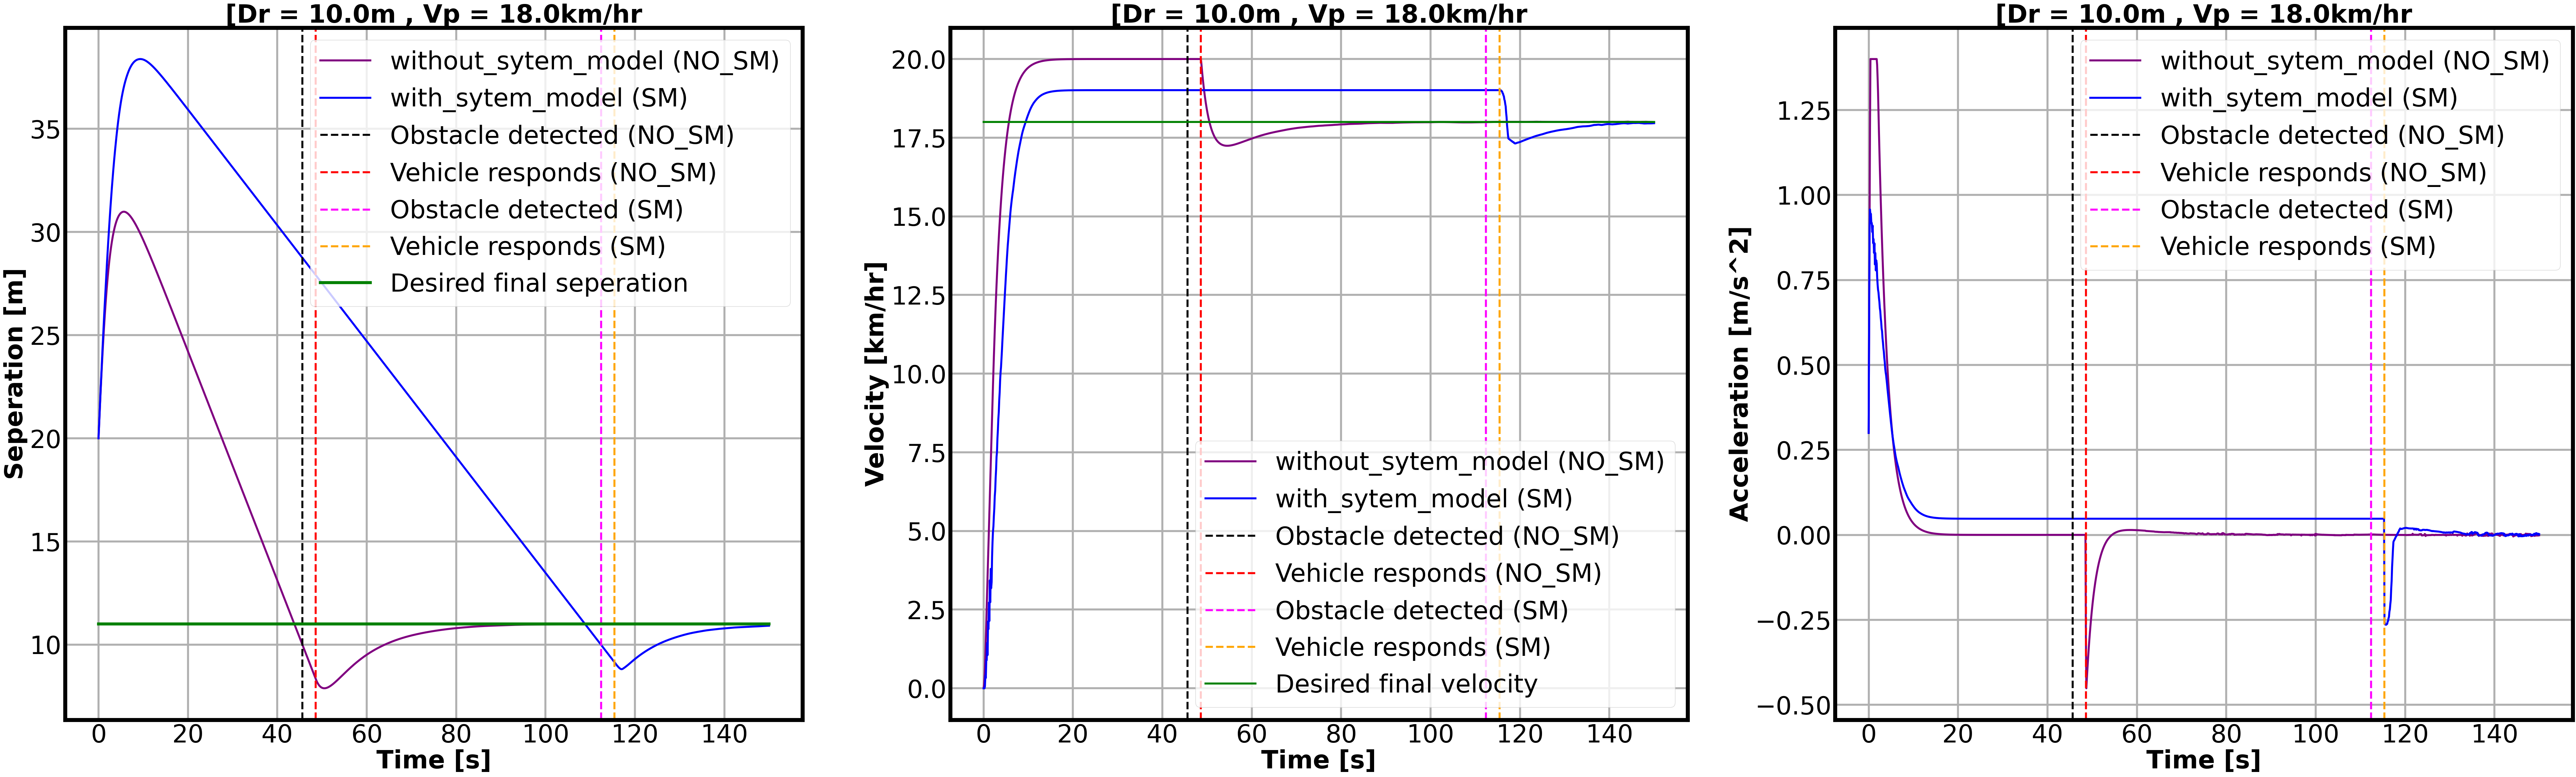

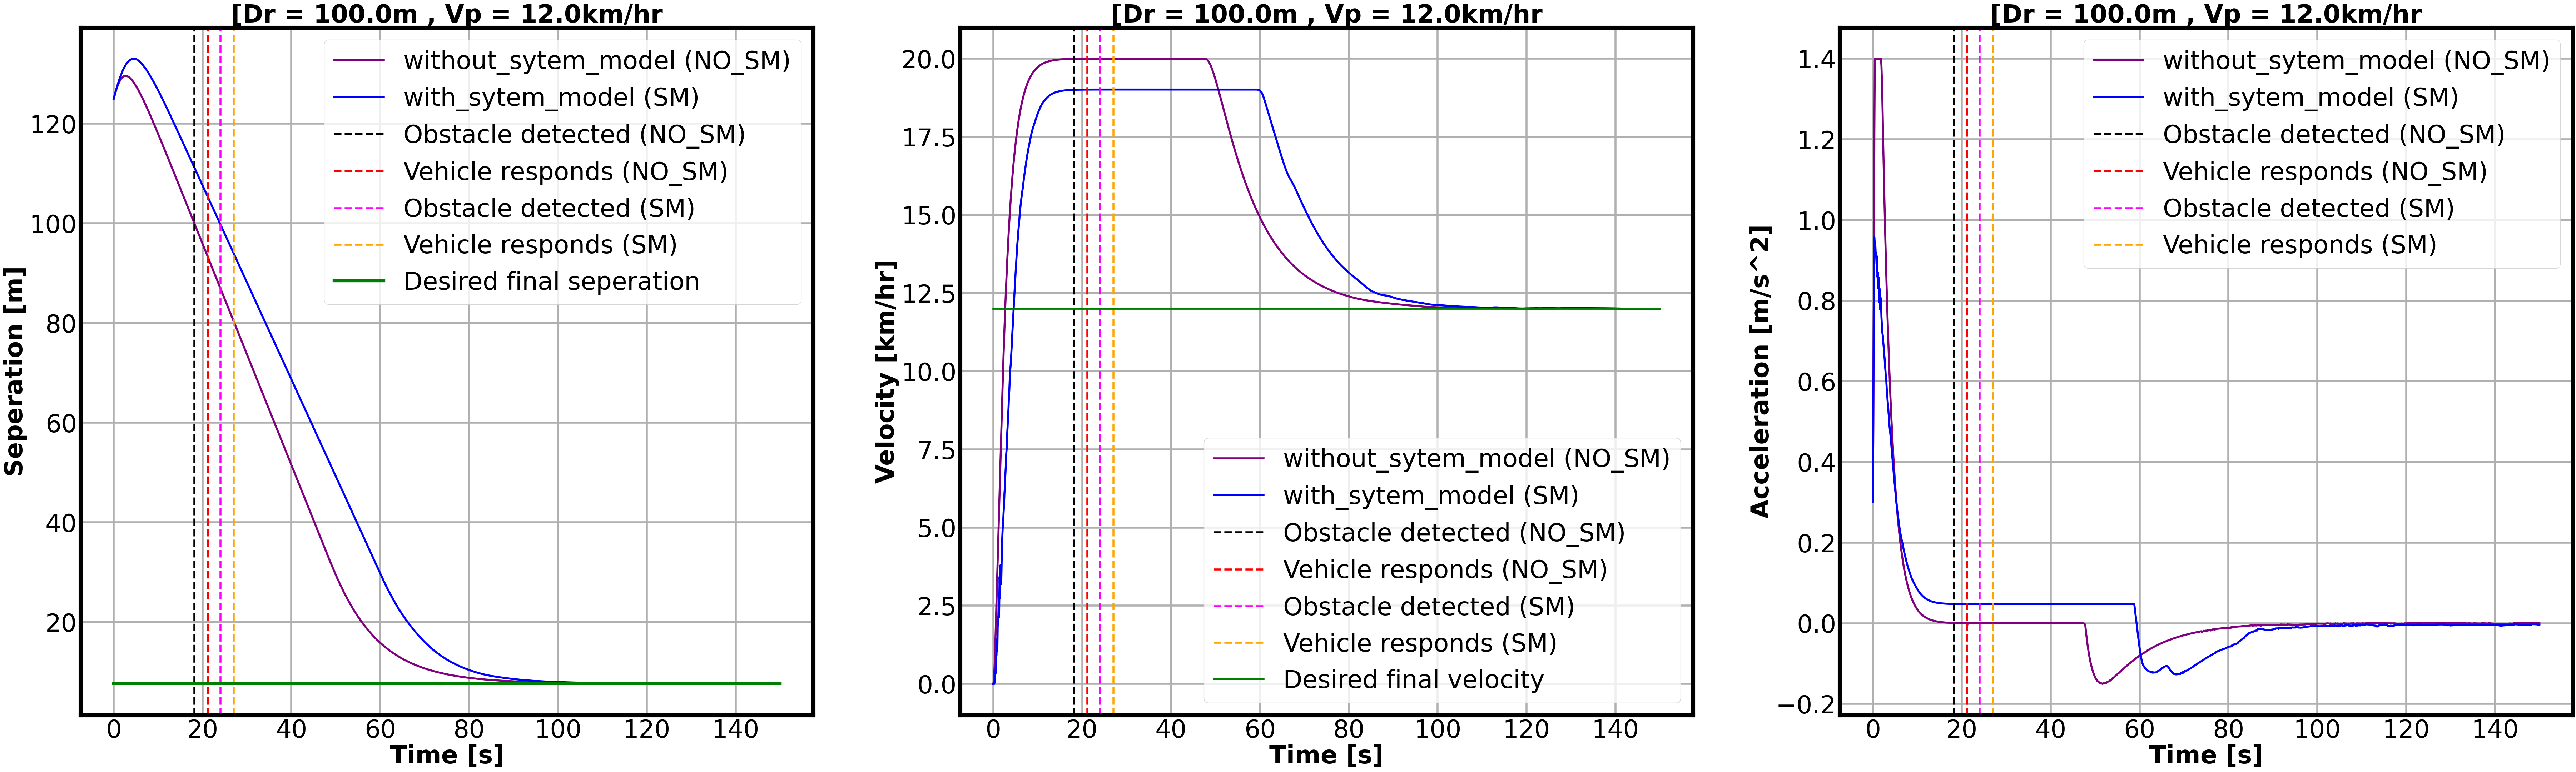

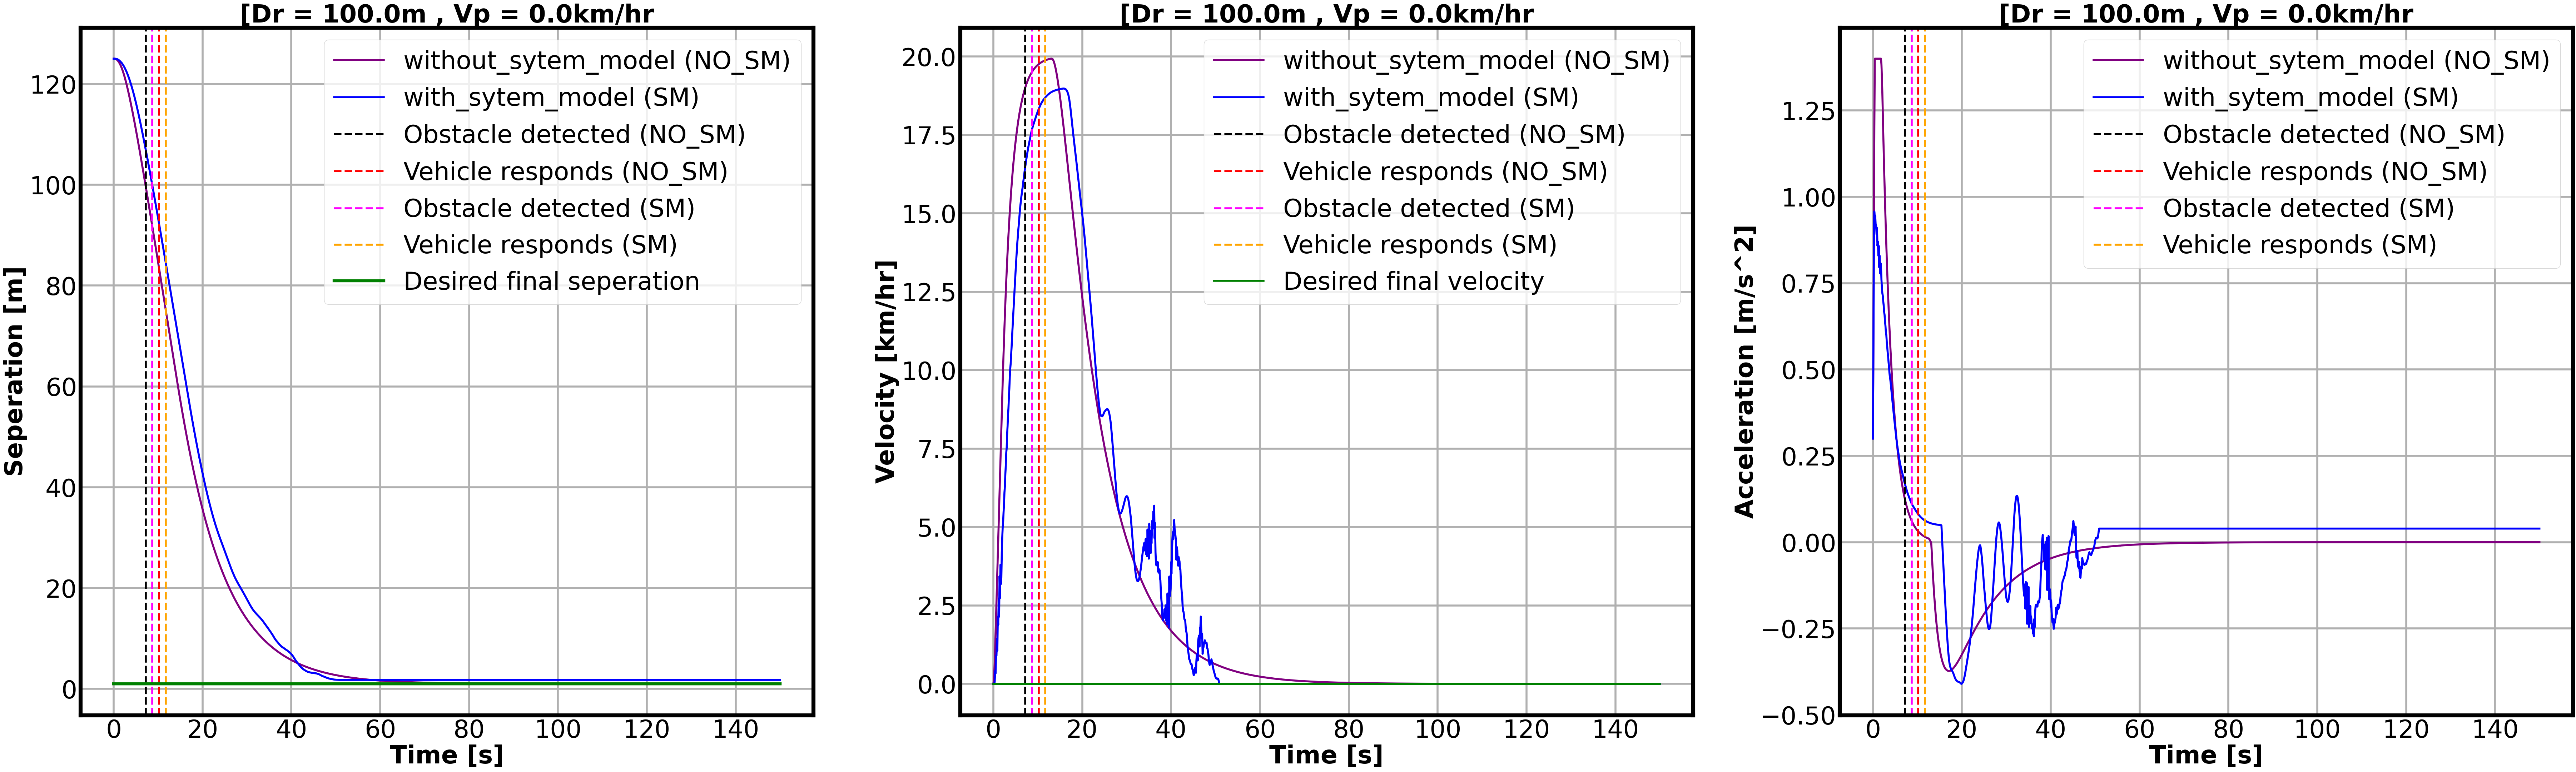

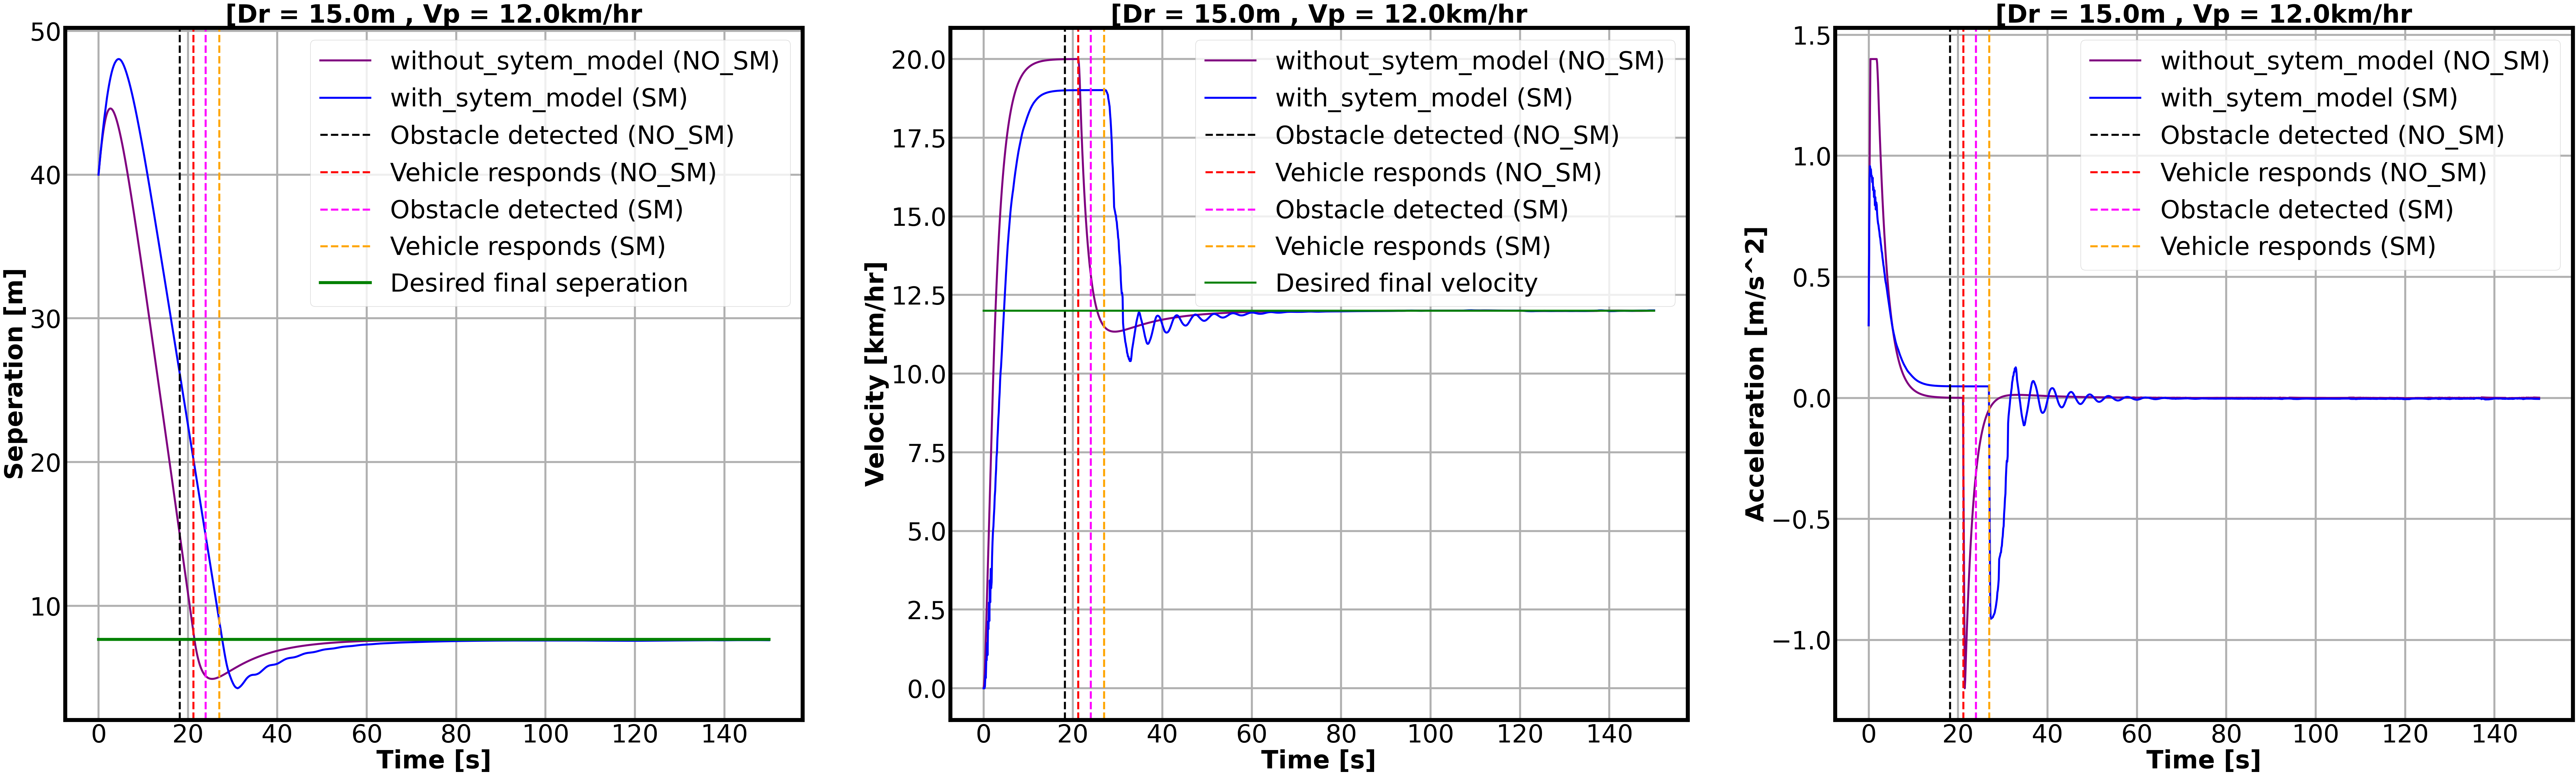

In [6]:
for i in range(len(store_times_without_system_model)):
    plot([store_times_without_system_model[i], store_times_with_system_model[i]], [store_accelerations_without_system_model[i], store_accelerations_with_system_model[i]], [store_velocities_without_system_model[i], store_velocities_with_system_model[i]], [store_seperations_without_system_model[i], store_seperations_with_system_model[i]], [store_detected_times_without_system_model[i], store_detected_times_with_system_model[i]], [store_start_reaction_times_without_sytem_model[i], store_start_reaction_times_with_sytem_model[i]], CP.Drs[i], CP.Vps[i])